## **Logistic Regression - Gender Classification Dataset**


### **Step 1: Import Library**

In [1]:
import pandas as pd

### **Step 2: Load Dataset**

In [2]:
df = pd.read_csv("gender_classification.csv")

### **Step 3: Explore the Data**

In [5]:
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64
Duplicate rows: 1768


### **Step 4: Remove Duplicates**

In [6]:
df = df.drop_duplicates()
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows after removal: 0


### **Step 5: Encode Target Variable**

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
print(df["gender"].value_counts())

gender
1    1783
0    1450
Name: count, dtype: int64


### **Separate Features (X) and Target (y)**

In [8]:
X = df.drop("gender", axis=1)
y = df["gender"]

print("Features:", X.columns.tolist())
print("Target shape:", y.shape)

Features: ['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide', 'nose_long', 'lips_thin', 'distance_nose_to_lip_long']
Target shape: (3233,)


### **Step 7: Train-Test Split**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2263, 7)
Testing size: (970, 7)


### **Step 8: Train the Model**


In [10]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### **Step 9: Evaluate the Model**

In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Female", "Male"]))

Accuracy: 0.9556701030927836

              precision    recall  f1-score   support

      Female       0.96      0.95      0.95       457
        Male       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970



### **Step 10: Confusion Matrix**

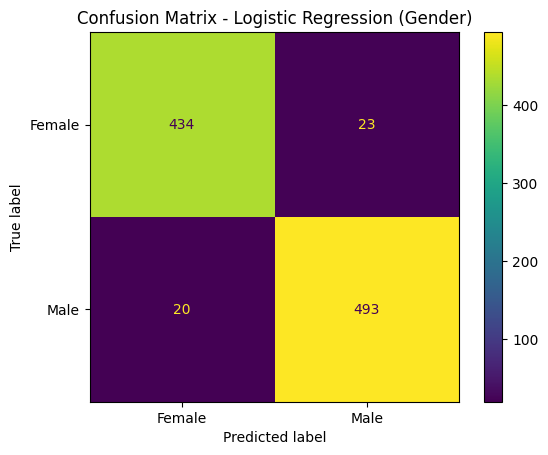

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression (Gender)")
plt.show()

### **Step 11: External Prediction**

In [13]:
new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]
new_data_df = pd.DataFrame(new_data, columns=X.columns)

result = log_reg.predict(new_data_df)[0]
print("Predicted Gender:", le.inverse_transform([result])[0])

Predicted Gender: Male
